# Rafael TCC - Projeto 04
## Análise Multivariada: Linhagens e Pedigree
Modelagem econométrica para isolar o efeito ceteris paribus das linhagens sobre o preço do sêmen Nelore (ANCP)

### Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


### Leitura dos Dados e Mapeamento das Dummies de Linhagem

In [2]:
# 1. Carregar base de touros válidos da ANCP (N = 115)
programa = 'ANCP'
df_ancp = pd.read_csv(f'Dados/CSV/NeloreCRV_{programa}_valido.csv')

# 2. Carregar dados gerais contendo a genealogia
df_geral = pd.read_csv('Dados/CSV/NeloreCRV_Dados_Gerais.csv')

# 3. Cruzamento (Merge)
cols_genealogia = ['crv_code', 'criador', 'proprietario', 'linhagem', 'pai', 'avo_paterno', 'avo_materno']
df_linhagens = pd.merge(
    df_ancp, 
    df_geral[cols_genealogia], 
    left_on='CRV_COD', 
    right_on='crv_code', 
    how='inner'
)

# 4. Mapeamento das variáveis binárias (dummies) dos Troncos Genéticos
troncos = {
    'TRONCO_EAO': lambda r: 1 if any('EAO' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME'], r['criador']]) else 0,
    'TRONCO_REM': lambda r: 1 if any('REM' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_NAVIRAI': lambda r: 1 if any(('NAVIRAI' in str(x).upper() or 'NAVIRAÍ' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_COLONIAL': lambda r: 1 if any(('COL' in str(x).upper() or 'COLONIAL' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_MATINHA': lambda r: 1 if any(('MAT' in str(x).upper() or 'MATINHA' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_LEMGRUBER_MN': lambda r: 1 if any((' MN' in str(x).upper() or 'MUNDO NOVO' in str(x).upper() or 'LEMGRUBER' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_IZ': lambda r: 1 if any(('IZ' in str(x).upper() or 'SERTÃOZINHO' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0
}

for nome, func in troncos.items():
    df_linhagens[nome] = df_linhagens.apply(func, axis=1)

print("=" * 80)
print(f"BASE PREPARADA COM SUCESSO: N = {len(df_linhagens)} touros mapeados com variáveis dummies")
print("=" * 80)

BASE PREPARADA COM SUCESSO: N = 115 touros mapeados com variáveis dummies


### Random Forest Feature Importance de Linhagens

RANKING RANDOM FOREST: IMPORTÂNCIA RELATIVA DAS LINHAGENS NA FORMAÇÃO DO PREÇO


,Linhagem,Importância Relativa (%),Importância Acumulada (%)
0,EAO,24.58,24.58
1,REM,22.79,47.37
2,MATINHA,17.49,64.86
3,LEMGRUBER_MN,16.31,81.17
4,COLONIAL,11.35,92.52
5,IZ,5.15,97.67
6,NAVIRAI,2.33,100.00


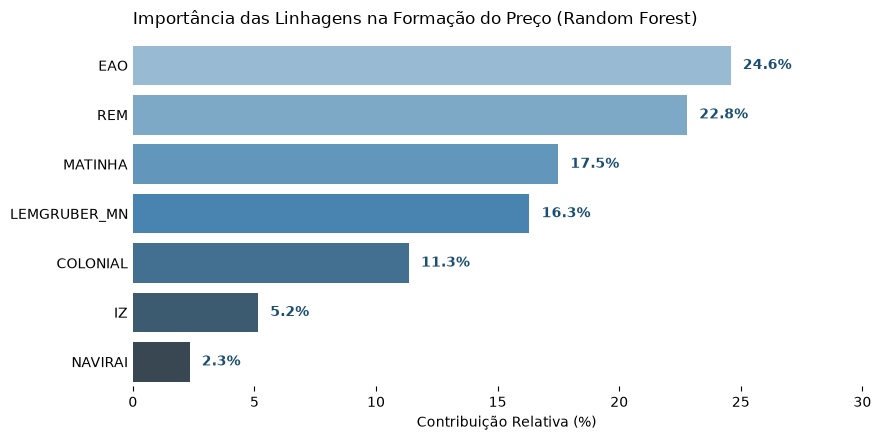

In [3]:
# 1. Definir matriz X e vetor y
cols_troncos = list(troncos.keys())
X_rf = df_linhagens[cols_troncos].copy()
y_rf = df_linhagens['SEMEM'].copy()

# 2. Ajuste do Modelo Random Forest (500 árvores)
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_rf, y_rf)

# 3. Tabela de Importância Relativa
df_rf_imp = pd.DataFrame({
    'Linhagem': [c.replace('TRONCO_', '') for c in cols_troncos],
    'Importância Relativa (%)': (rf.feature_importances_ * 100).round(2)
}).sort_values(by='Importância Relativa (%)', ascending=False).reset_index(drop=True)

df_rf_imp['Importância Acumulada (%)'] = df_rf_imp['Importância Relativa (%)'].cumsum().round(2)

print("=" * 80)
print("RANKING RANDOM FOREST: IMPORTÂNCIA RELATIVA DAS LINHAGENS NA FORMAÇÃO DO PREÇO")
print("=" * 80)
display(df_rf_imp)

# 4. Gráfico Horizontal de Importância
plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=df_rf_imp, 
    x='Importância Relativa (%)', 
    y='Linhagem', 
    palette='Blues_d', 
    hue='Linhagem', 
    legend=False
)

for i, row in enumerate(df_rf_imp.itertuples()):
    plt.text(
        row._2 + 0.5, 
        i, 
        f"{row._2:.1f}%", 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='bold', 
        color='#1b4f72'
    )

plt.title('Importância das Linhagens na Formação do Preço (Random Forest)', fontsize=12, loc='left', pad=12)
plt.xlabel('Contribuição Relativa (%)', fontsize=10)
plt.ylabel('')
plt.xlim(0, df_rf_imp['Importância Relativa (%)'].max() * 1.25)
plt.tick_params(axis='y', length=0)
sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()


### Regressão Hedônica Multivariada OLS das Linhagens

In [4]:
# 1. Definição do modelo OLS com todas as linhagens simultaneamente
X_ols = df_linhagens[cols_troncos].copy()
X_ols_const = sm.add_constant(X_ols)
y_ols = df_linhagens['SEMEM'].copy()

# 2. Ajuste do modelo
modelo_linhagens = sm.OLS(y_ols, X_ols_const).fit()

# 3. Tabela de Coeficientes Formatada
tabela_linhagens = pd.DataFrame({
    'Coeficiente (Beta R$)': modelo_linhagens.params.round(3),
    'Erro Padrão': modelo_linhagens.bse.round(3),
    'Estatística t': modelo_linhagens.tvalues.round(2),
    'p-valor': modelo_linhagens.pvalues.round(4)
})

def formatar_significancia(p):
    if p < 0.01: return '*** (Signif. a 1%)'
    if p < 0.05: return '** (Signif. a 5%)'
    if p < 0.10: return '* (Signif. a 10%)'
    return 'Não significativo'

tabela_linhagens['Significância'] = tabela_linhagens['p-valor'].apply(formatar_significancia)

nomes_formatados = {c: c.replace('TRONCO_', '') for c in cols_troncos}
nomes_formatados['const'] = 'Preço Base (Intercepto)'
tabela_linhagens.index = [nomes_formatados.get(i, i) for i in tabela_linhagens.index]

print("=" * 85)
print(f"REGRESSÃO MULTIVARIADA DE LINHAGENS (R² = {modelo_linhagens.rsquared:.3f} | R² Ajustado = {modelo_linhagens.rsquared_adj:.3f})")
print(f"Estatística F = {modelo_linhagens.fvalue:.2f} (p-valor do Modelo = {modelo_linhagens.f_pvalue:.4f})")
print("=" * 85)
display(tabela_linhagens)


REGRESSÃO MULTIVARIADA DE LINHAGENS (R² = 0.087 | R² Ajustado = 0.027)
Estatística F = 1.46 (p-valor do Modelo = 0.1909)


,Coeficiente (Beta R$),Erro Padrão,Estatística t,p-valor,Significância
Preço Base (Intercepto),31.194,1.438,21.70,0.0000,*** (Signif. a 1%)
EAO,9.594,3.168,3.03,0.0031,*** (Signif. a 1%)
REM,0.924,1.399,0.66,0.5102,Não significativo
NAVIRAI,3.231,4.030,0.80,0.4245,Não significativo
COLONIAL,0.842,1.537,0.55,0.5852,Não significativo
MATINHA,-0.561,1.754,-0.32,0.7498,Não significativo
LEMGRUBER_MN,0.317,1.742,0.18,0.8560,Não significativo
IZ,-0.161,2.174,-0.07,0.9411,Não significativo


### Diagnóstico de Multicolinearidade (VIF)

In [5]:
# Cálculo do Fator de Inflação da Variância (VIF)
vif_linhagens = pd.DataFrame()
vif_linhagens['Linhagem'] = [c.replace('TRONCO_', '') for c in cols_troncos]
vif_linhagens['VIF'] = [variance_inflation_factor(X_ols.values, i) for i in range(X_ols.shape[1])]
vif_linhagens['VIF'] = vif_linhagens['VIF'].round(2)
vif_linhagens['Diagnóstico'] = vif_linhagens['VIF'].apply(
    lambda x: 'Excelente (< 5)' if x < 5 else ('Aceitável (< 10)' if x < 10 else 'Alerta (> 10)')
)

print("=" * 80)
print("DIAGNÓSTICO DE MULTICOLINEARIDADE ENTRE AS LINHAGENS (VIF)")
print("=" * 80)
display(vif_linhagens)

DIAGNÓSTICO DE MULTICOLINEARIDADE ENTRE AS LINHAGENS (VIF)


,Linhagem,VIF,Diagnóstico
0,EAO,1.07,Excelente (< 5)
1,REM,1.22,Excelente (< 5)
2,NAVIRAI,1.06,Excelente (< 5)
3,COLONIAL,1.14,Excelente (< 5)
4,MATINHA,1.04,Excelente (< 5)
5,LEMGRUBER_MN,1.20,Excelente (< 5)
6,IZ,1.22,Excelente (< 5)


### Gráfico dos Coeficientes da Regressão

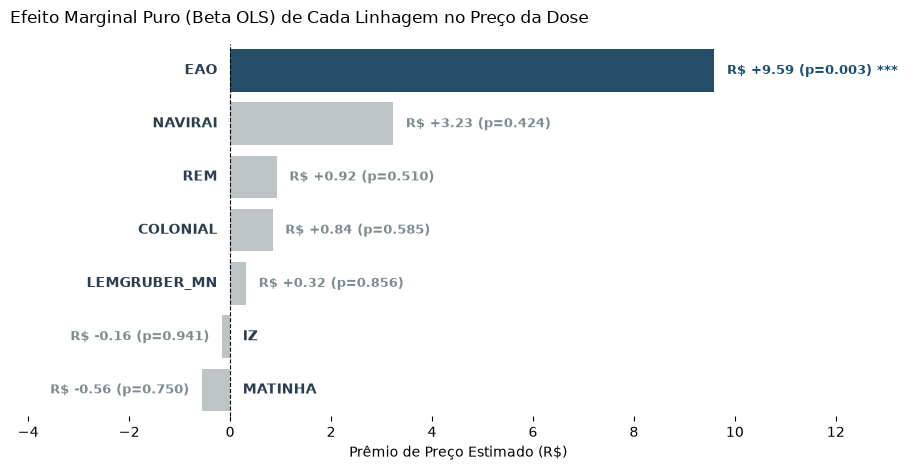


CONCLUSÃO: Sob controle simultâneo (ceteris paribus), apenas a linhagem EAO apresenta
prêmio estatisticamente significante (p = 0.003), agregando R$ 9.59 à dose de sêmen.


In [11]:
# Gráfico com os Betas da Regressão (excluindo a constante)
df_betas = tabela_linhagens.drop('Preço Base (Intercepto)').reset_index()
df_betas.rename(columns={'index': 'Linhagem'}, inplace=True)
df_betas = df_betas.sort_values(by='Coeficiente (Beta R$)', ascending=False)

plt.figure(figsize=(9.5, 4.8))
cores_beta = ['#1b4f72' if p < 0.05 else '#bdc3c7' for p in df_betas['p-valor']]

ax = sns.barplot(
    data=df_betas, 
    x='Coeficiente (Beta R$)', 
    y='Linhagem', 
    palette=cores_beta, 
    hue='Linhagem', 
    legend=False
)

# Oculta os rótulos padrão do eixo Y para aplicarmos o posicionamento dinâmico em lados opostos
ax.yaxis.set_visible(False)

# Linha vertical tracejada de referência no zero
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Posicionamento dinâmico: se o rótulo está na direita, o valor fica na esquerda, e vice-versa
for i, row in enumerate(df_betas.itertuples()):
    nome = row.Linhagem
    val = row._2   # Coeficiente Beta
    pval = row._5  # p-valor
    
    texto_valor = f"R$ {val:+.2f} (p={pval:.3f})"
    if pval < 0.01:
        texto_valor += " ***"
        
    cor_valor = '#1b4f72' if pval < 0.05 else '#7f8c8d'
    
    if val >= 0:
        # 1. Rótulo da Linhagem no lado ESQUERDO da linha zero
        ax.text(
            -0.25, i, nome, 
            va='center', ha='right', 
            fontsize=10, fontweight='bold', color='#2c3e50'
        )
        # 2. Valor no lado DIREITO da barra
        ax.text(
            val + 0.25, i, texto_valor, 
            va='center', ha='left', 
            fontsize=9, fontweight='bold', color=cor_valor
        )
    else:
        # 1. Rótulo da Linhagem no lado DIREITO da linha zero
        ax.text(
            0.25, i, nome, 
            va='center', ha='left', 
            fontsize=10, fontweight='bold', color='#2c3e50'
        )
        # 2. Valor no lado ESQUERDO da barra
        ax.text(
            val - 0.25, i, texto_valor, 
            va='center', ha='right', 
            fontsize=9, fontweight='bold', color=cor_valor
        )

# Título e formatação estética
ax.set_title('Efeito Marginal Puro (Beta OLS) de Cada Linhagem no Preço da Dose', fontsize=12, loc='left', pad=15)
ax.set_xlabel('Prêmio de Preço Estimado (R$)', fontsize=10)
ax.set_ylabel('')

# Margens ajustadas para os textos não cortarem nas extremidades
ax.set_xlim(df_betas['Coeficiente (Beta R$)'].min() - 3.8, df_betas['Coeficiente (Beta R$)'].max() + 3.8)

sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()

print("\nCONCLUSÃO: Sob controle simultâneo (ceteris paribus), apenas a linhagem EAO apresenta")
print("prêmio estatisticamente significante (p = 0.003), agregando R$ 9.59 à dose de sêmen.")
